# 111_重新认识函数

In [ ]:
#1 函数也是对象

a1 = 100
a2 = 'hello'
a3 = [10, 20, 30]
def welcome():
    print('你好啊')


print(type(a1))
print(type(a2))
print(type(a3))
print(type(welcome))

In [ ]:
# 2函数可以像对象一样，动态添加属性
def welcome():
    print('你好')

welcome.desc = "这是一个用于打招呼的函数" # 函数像对象一样添加属性
welcome.version = 1.0
print(welcome.__dict__) # 返回字典，显示desc和version

welcome()

In [ ]:
#3 函数可以赋值给变量
def welcome():
    print('你好啊')

say_hello = welcome

say_hello() # 赋值给变量并且调用

welcome()

In [ ]:
# 4 可变参数

# 1. f — f-string（格式化字符串）
# f 是 Python 3.6+ 引入的一种字符串格式化语法，放在字符串引号前面。
# 2. id() — 获取对象的内存地址
# id() 是 Python 的内置函数，用于返回一个对象的唯一标识符（通常是该对象在内存中的地址，具体取决于 Python 实现，CPython 中就是内存地址）。
# 返回一个整数
# 每个对象在生命周期内 id 是唯一且不变的
# 如果两个变量指向同一个对象，它们的 id 相同
# 常用于判断两个变量是否引用同一个对象（类似 is 关键字）


def welcome(data):  # 形参
    print(f'2. 函数收到的data是：{data}, 地址是: {id(data)}')
    data = 888 # 修改data入参，不会改动外面的a， 此时会新建一个变量和地址, int是不可变参数
    print(f'3. 函数收到的data是：{data}, 地址是: {id(data)}')

a = 666
print(f'1. 函数外侧的值是: {a}, 地址是: {id(a)}')
welcome(a)
print(f'4. 函数调用后a的值是: {a}, 地址是: {id(a)}')


In [ ]:
# 4 可变参数
def welcome(data):
    print(f'函数收到的data是：{data},地址是：{id(data)}')
    data[2] = 99  # 修改对象data入惨，会改变外面的a， 且地址不改变，是同一个内存变量，因为data和a都是指向同一个空间
    print(f'被修改后的data时：{data},地址是：{id(data)}')

a = [10, 20, 30]
print(f'函数外侧a的值是：{a}, 地址是: {id(a)}')
welcome(a)
print(f'函数调用后a的值：{a}, 地址是: {id(a)}')

In [ ]:
# 5 函数也可以作为参数
def welcome():
    print('hello')

def caller(f):
    print('caller start')
    f()

caller(welcome)

In [ ]:
# 6 函数作为返回值
def welcome():
    print('hello')
    def show_msg(msg):
        print(msg)
    return show_msg


result = welcome()
result('syp')

# 或者
welcome()('syp2')


# 112 多返回值+函数的打包与解包

In [ ]:
# 多返回值
def calculate(x, y):
    res1 = x + y
    res2 = x - y
    return res1, res2 # 输出tuple

def calculate2(x, y):
    res1 = x + y
    res2 = x - y
    return [res1, res2] # 输出list


result = calculate(10, 20)
r1, r2 = result

print(result, r1, r2)


In [18]:
# 打包与解包
def show_info(*args, **kwargs):
    print(args)
    print(kwargs)


nums = (10, 20, 30)
person = {'name': '张三', 'age': 18}

show_info(*nums, **person)

(10, 20, 30)
{'name': '张三', 'age': 18}


在 Python 中，函数参数分为**位置参数**和**关键字参数**，核心区别在于**传参时是否依赖顺序**。

### 1. 位置参数
按**从左到右的顺序**依次匹配形参，顺序不能错。

```python
def greet(name, age):
    print(f"{name} is {age} years old")

# ✅ 正确：按顺序传入
greet("Alice", 25)       # name="Alice", age=25

# ❌ 错误：顺序反了，语义就错了
greet(25, "Alice")       # name=25, age="Alice" → 逻辑混乱
```

### 2. 关键字参数
通过 **`形参名=值`** 的形式传参，**不依赖顺序**，可读性更强。

```python
def greet(name, age):
    print(f"{name} is {age} years old")

# ✅ 用关键字传参，顺序随意
greet(age=25, name="Alice")   # 结果完全一样
greet(name="Alice", age=25)   # 同上
```

### 3. 混合使用（常见场景）
两者可以混用，但有一条铁律：**位置参数必须在关键字参数前面**。

```python
def create_user(name, age, city="Beijing", role="user"):
    print(f"{name}, {age}, {city}, {role}")

# ✅ 前两个用位置，后两个用关键字（最常用写法）
create_user("Alice", 25, city="Shanghai", role="admin")

# ✅ 全部用关键字
create_user(name="Alice", age=25, city="Shanghai", role="admin")

# ❌ 报错！关键字参数后面不能再跟位置参数
# create_user("Alice", age=25, "Shanghai")  # SyntaxError
```

### 4. 进阶：强制限定参数类型（Python 3.8+）

```python
def func(pos_only, /, normal, *, kw_only):
    pass

# pos_only: 只能用位置参数（/ 左边）
# normal:   位置或关键字都行
# kw_only:  只能用关键字参数（* 右边）

func(1, 2, kw_only=3)      # ✅
func(1, normal=2, kw_only=3) # ✅
# func(pos_only=1, 2, kw_only=3)  # ❌ pos_only 不接受关键字
# func(1, 2, 3)                   # ❌ kw_only 不接受位置
```

### 📊 快速对比

| 特性 | 位置参数 | 关键字参数 |
| :--- | :--- | :--- |
| 传参方式 | 按顺序 | `形参名=值` |
| 顺序要求 | **严格** | 无要求 |
| 可读性 | 参数多时差 | 好，自文档化 |
| 适用场景 | 必填、含义明确的少数参数 | 可选参数、配置项、参数较多时 |

> 💡 **最佳实践**：参数少且含义明确时用位置参数；参数多、有默认值、或容易混淆时，**优先使用关键字参数**，代码可读性会大幅提升。

In [13]:
nums = (10, 20, 30)

def show_info(*args):
    print(args)

show_info(10, 10, 10)
show_info(*nums)

(10, 10, 10)
(10, 20, 30)


In [26]:
person = {'name': '张三', 'age': 18}
def show_info(**kwargs):
    print(kwargs)

show_info(key=123, a=1, b=2, c=3)
show_info(**person)

{'key': 123, 'a': 1, 'b': 2, 'c': 3}
{'name': '张三', 'age': 18}


# 113 高阶函数

In [27]:
def welcome():
    print('你好')

def caller(f): # 参数是函数
    print('call函数开始调用')
    f()

caller(welcome)

call函数开始调用
你好


In [28]:
def outer(): # 返回值是函数
    print('我是outer')
    def inner():
        print('我是inner')
    return inner

In [29]:
# 意义
def info(msg):
    return '[提示]' + msg
def warn(msg):
    return '[警告]' + msg
def error(msg):
    return '[错误]' + msg

def log(fun, text): # 入参有函数作为参数
    print(fun(text))

log(info, '文件保存成功！')
log(warn, '磁盘空间不足！')
log(error, '该用户不存在！')

[提示]文件保存成功！
[警告]磁盘空间不足！
[错误]该用户不存在！


## 条件表达式

In [32]:
# 最后得到一个值
print(3 + 5)
print('abc' * 3)
print(5 > 3)
print('y' in 'Python')
print(len('hello'))

8
abcabcabc
True
True
5


In [34]:
# 条件表达式
age = 20
text = '成年' if age >= 18 else '未成年'
text

'成年'

In [35]:
rain = True
food = '外卖' if rain else '出去吃'

is_vip = True
disscount = 0.8 if is_vip else 1.0

is_login = True
msg = '欢迎回来' if is_login else '请先登录'

## 匿名函数

In [36]:
def add(x, y):
    return x + y

a = lambda x,y: x + y

print(add(1, 2))
print(a(1, 2))

3
3


In [37]:
is_adult = lambda age : ('成年' if age >= 18 else '未成年')
print(is_adult(18))
print(is_adult(13))


成年
未成年


## 几个数据处理函数

In [38]:
# map


In [39]:
# filter

In [40]:
# sorted


In [41]:
# reduce

# 列表推导式

# 装饰器

## 函数装饰器

In [53]:


def add(x, y):
    res = x + y
    print(f'{x}和{y}相加的结果是: {res}')
    return res

def say_hello(func):
    def wrapper(*args, **kwargs): # 别的函数支持4个5个参数。 打包参数
        print('你好，我要开始调用了')
        res = func(*args, **kwargs) # 解构参数
        return res
    return wrapper # add_pro就是wrapper


# 正常调用add函数
result = add(10, 20)
print(result)

# 不修改add函数前提下，给add函数增加额外的功能，  例如先打印一句欢迎语
# （1 有可能有一个函数是别人写的，
# 2 有可能很多人调用add函数，有人不需要欢迎语），就要借助装饰器
# 使用装饰器实现
# add_pro = say_hello(add)
# result = add_pro(10, 20)
# print(result)

# 可以同名，修改add函数，
# 手动装饰， 写起来麻烦， 不推荐， 推荐@装饰器名，  语法糖
add = say_hello(add)
result = add(10, 20)
print(result)

10和20相加的结果是: 30
30
你好，我要开始调用了
10和20相加的结果是: 30
30


In [56]:
@say_hello # 等价于 add = say_hello(add)，注释相当于没有改动
def add(x, y, z):
    res = x + y + z
    print(f'{x}和{y}和{z}相加的结果是: {res}')
    return res

res = add(10, 20, 30)

你好，我要开始调用了
10和20和30相加的结果是: 60


接收被装饰的函数、同时返回新函数（wrapper）
装饰器“吐出来”的是 wrapper 函数，以后别人调用的也是 wrapper 函数。 （原始函数的外层包裹了wrapper函数）
为了保证参数的兼容性，wrapper 函数要通过 *args 和 **kwargs 接收参数。
wrapper 函数中主要做的是：
1. 调用原函数（被装饰的函数）、
2. 执行其它逻辑，
3. 但要记得将原函数的返回值 return 出去。

### 进阶：带参数的装饰器
三层嵌套：
1. 外层：say_hello， 接受配置
2. 中间层：outer：接受函数
3. 内层：wrapper：接收具体参数

In [57]:
def say_hello(msg):
    def outer(func):
        def wrapper(*args, **kwargs): # 别的函数支持4个5个参数。 打包参数
            print(f'你好，我要开始调用{msg}了')
            res = func(*args, **kwargs) # 解构参数
            return res
        return wrapper # add_pro就是wrapper

    return outer



@say_hello('加法')
def add(x, y, z):
    res = x + y + z
    print(f'{x}和{y}和{z}相加的结果是: {res}')
    return res

@say_hello('减法')  # 要交给say_hello函数，调用后的返回值的函数
def sub(x,y):
    res = x -y
    print(f'{x}和{y}相加的结果是: {res}')
    return res

res = add(10, 20, 30)
res2 = sub(10, 20)

你好，我要开始调用加法了
10和20和30相加的结果是: 60
你好，我要开始调用减法了
10和20相加的结果是: -10


### 进阶：多个装饰器一起使用

In [58]:
def test1(func):
    print('我是test1装饰器')
    def wrapper(*args, **kwargs):
        print('我是test1追加的逻辑')
        res = func(*args, **kwargs)
        return res
    return wrapper

def test2(func):
    print('我是test2装饰器')
    def wrapper(*args, **kwargs):
        print('我是test2追加的逻辑')
        res = func(*args, **kwargs)
        return res
    return wrapper

@test1
@test2
def add(x,y):  # 等价于add = test1(test2(add))
    res = x + y
    print(f'{x}和{y}相加的结果是{res}')
    return res

result = add(10, 20)
print(result)

我是test2装饰器
我是test1装饰器
我是test1追加的逻辑
我是test2追加的逻辑
10和20相加的结果是30
30


#### 执行顺序
下面是对原始add函数逻辑的修改， 先改函数，上面添加一行test2，再改函数，上面添加一行test1， 函数已经被修改三段逻辑
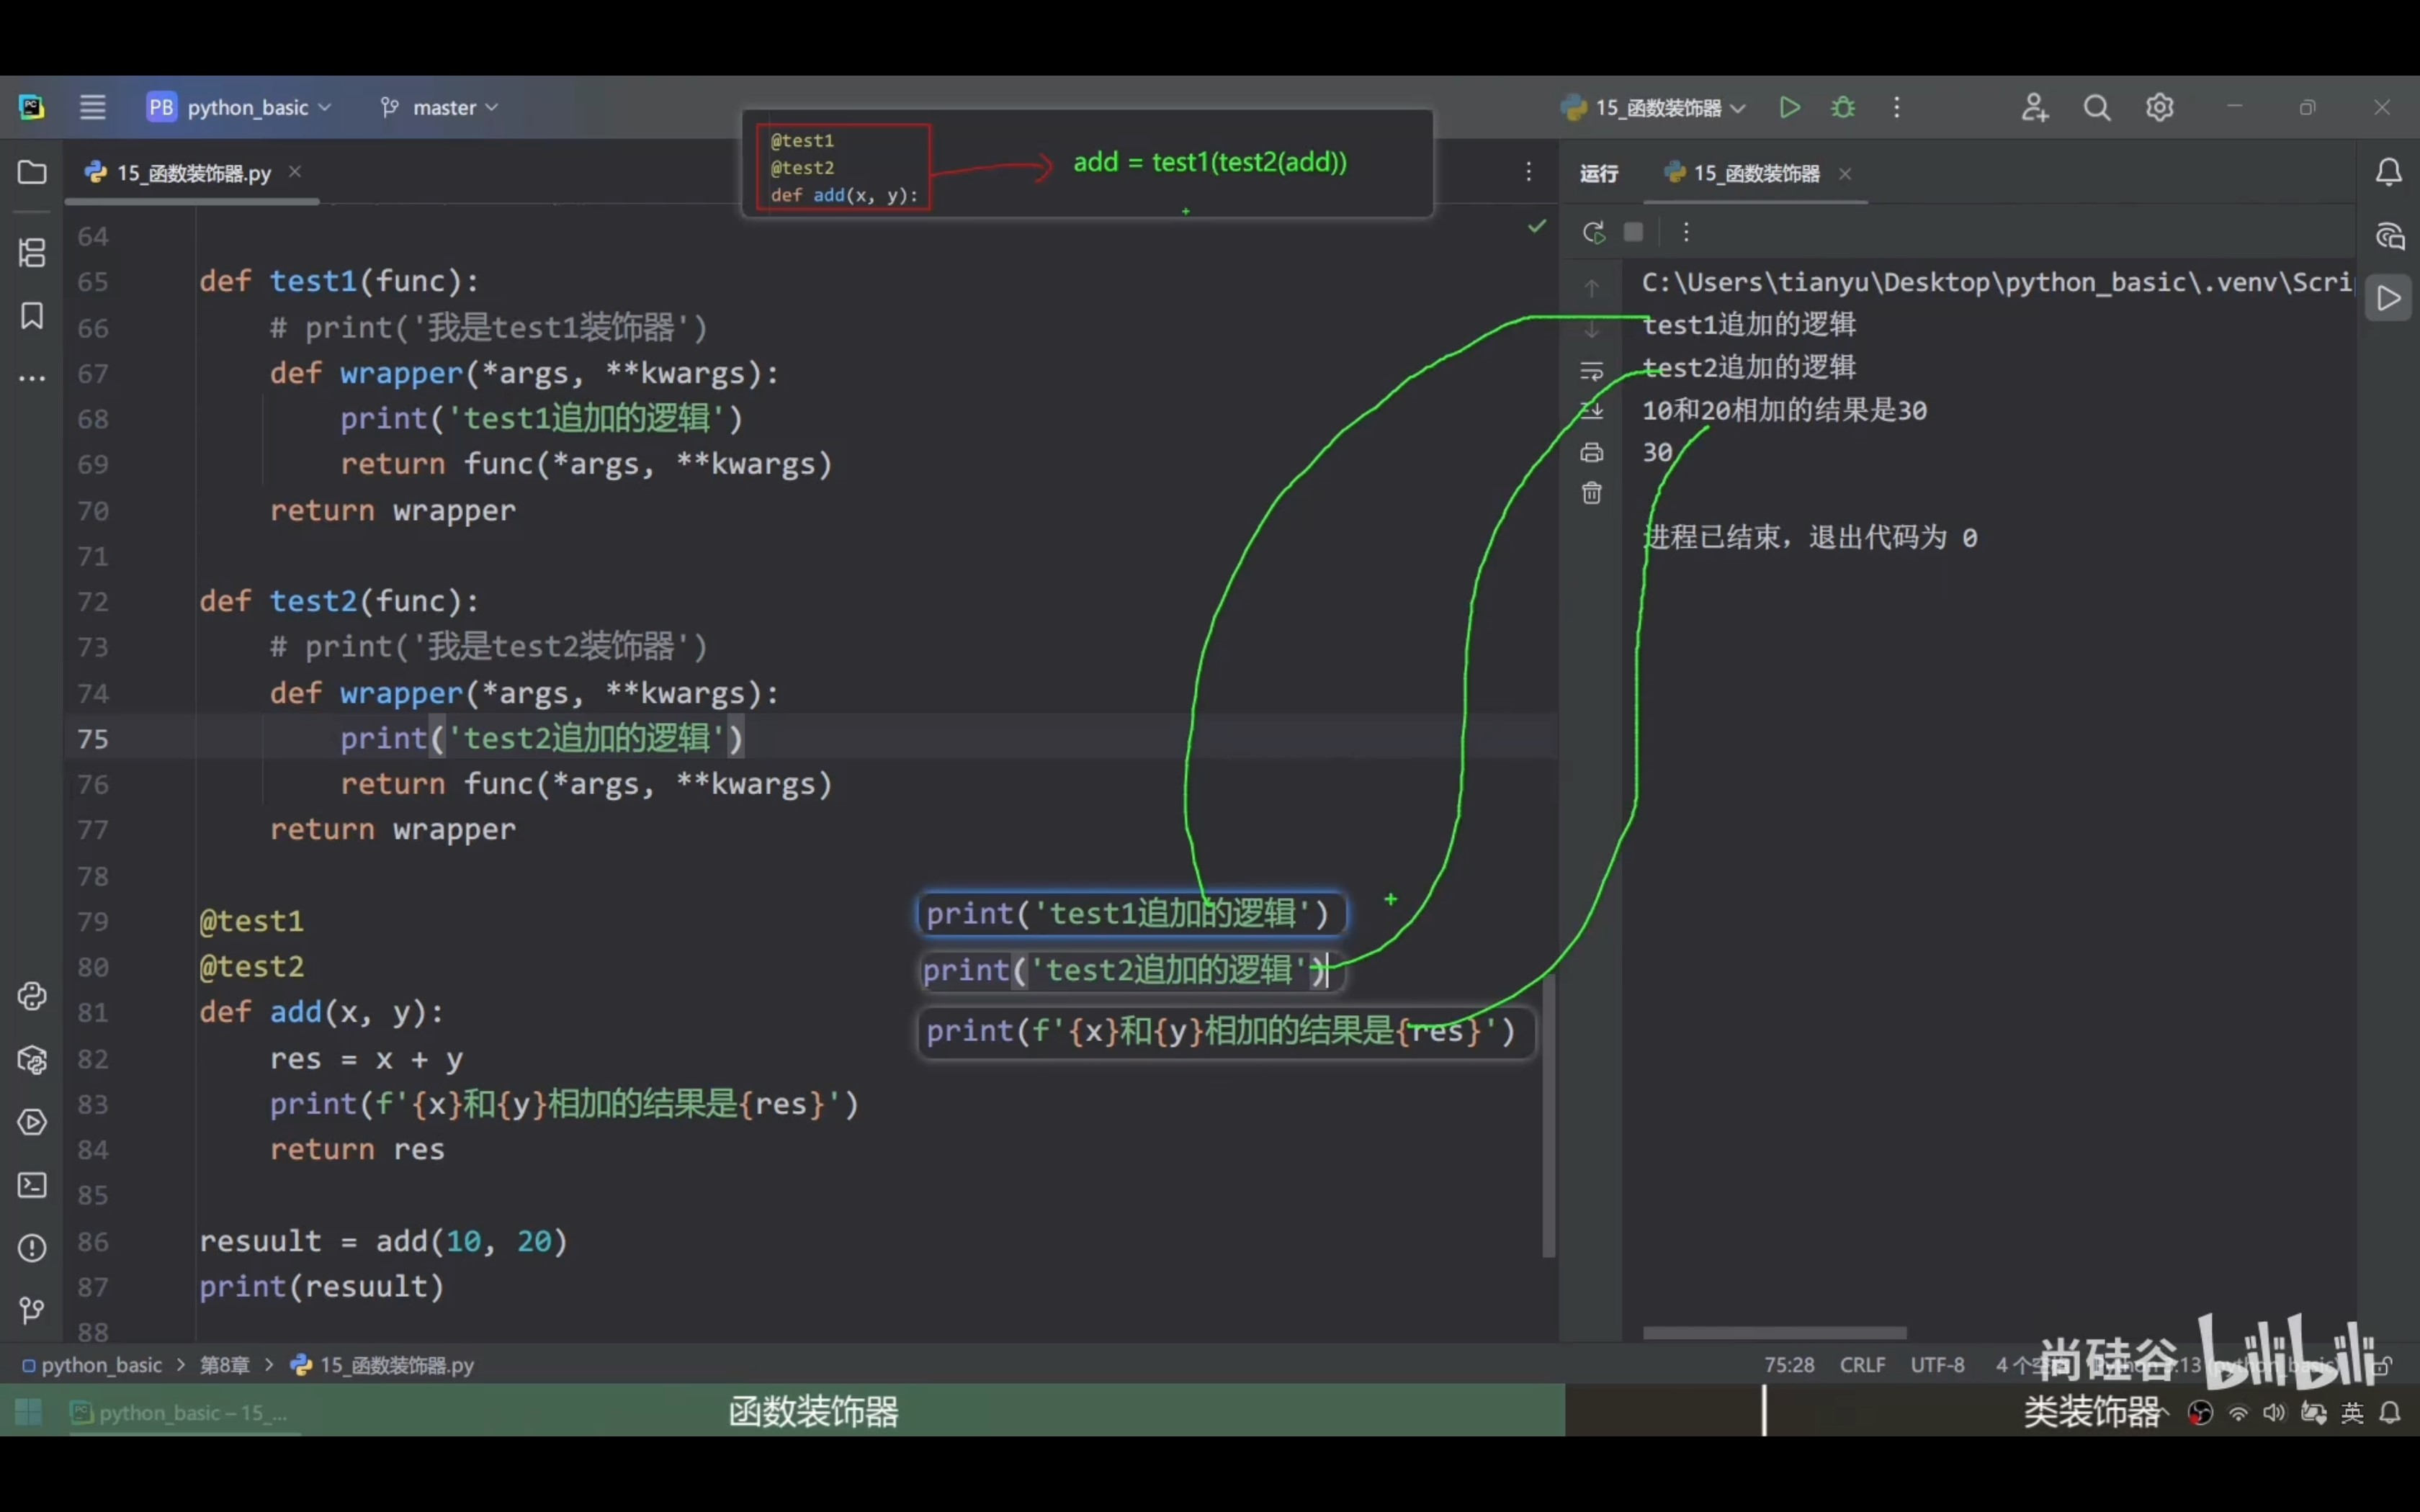

但是等价结果是 test1(test2(add))，  先执行test2装饰器，再执行test1装饰器
首先执行装饰器，再返回修改的结果，所以，我是。。装饰器，先打印出来
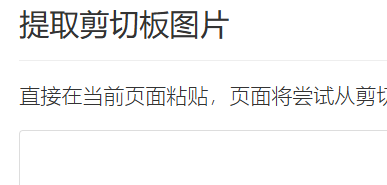

In [1]:
def test1(func):
    print('我是test1装饰器')
    def wrapper(*args, **kwargs):
        res = func(*args, **kwargs)
        print('我是test1追加的逻辑')
        return res

    return wrapper

def test2(func):
    print('我是test2装饰器')
    def wrapper(*args, **kwargs):
        res = func(*args, **kwargs)
        print('我是test2追加的逻辑')
        return res

    return wrapper

@test1
@test2
def add(x,y):  # 等价于add = test1(test2(add))
    res = x + y
    print(f'{x}和{y}相加的结果是{res}')
    return res

result = add(10, 20)
print(result)

我是test2装饰器
我是test1装饰器
10和20相加的结果是30
我是test2追加的逻辑
我是test1追加的逻辑
30


实际应用：在不改变原函数的前提下，给函数统一加上：日志，计时，校验，缓存等功能

 ## 类装饰器

定义
1. 包含__call__方法的类，就是类装饰器
2. __call__方法通常接收一个函数作为参数，并且返回一个新函数

调用
1. 像调用函数一样，去调用类装饰器的实例对象，就会触发__call__方法的调用

In [6]:
class SayHello:
    def __call__(self, func):
        def wrapper(*args, **kwargs):
            print('你好，我要开计算了')
            return func(*args, **kwargs)
        return wrapper


def add(x, y):
    res = x + y
    print(f'{x}和{y}相加的结果是{res}')
    return res

# 正常调用add函数
# result = add(10, 20)
# print(result)

# 使用SayHello 去装饰add函数（手动装饰）
# say = SayHello() # 得到一个实例对象
# add  = say(add)  # 之前是person.xxx，这里直接调用对象，因为有__call__方法
#
# result = add(10, 20)
# print(result)

# @语法糖方式，使用类装饰器
@SayHello()  # 必须要要要写()，来调用
def add(x, y):
    res = x + y
    print(f'{x}和{y}相加的结果是{res}')
    return res
result = add(10, 20)
print(result)

你好，我要开计算了
10和20相加的结果是30
30


带参数的类装饰器， 比带参数的函数装饰器简单,不用包很多层



In [8]:
class SayHello:
    def __init__(self, msg): # 需要传入参数
        self.msg = msg

    def __call__(self, func):
        def wrapper(*args, **kwargs):
            print(f'你好，我要开始{self.msg}计算了')
            return func(*args, **kwargs)
        return wrapper

@SayHello('加法') # 也可以传入更多参数， 更清晰，没有太多曾
def add(x, y):
    res = x + y
    print(f'{x}和{y}相加的结果是{res}')
    return res

result = add(10, 20)
print(result)

你好，我要开始加法计算了
10和20相加的结果是30
30


In [10]:
# 多个类装饰器的使用

class Test1:
    def __call__(self, func):
        print('Test1装饰器')
        def wrapper(*args, **kwargs):
            print('我是Test1追加的逻辑')
            return func(*args, **kwargs)
        return wrapper

class Test2:
    def __call__(self, func):
        print('Test2装饰器')
        def wrapper(*args, **kwargs):
            print('我是Test2追加的逻辑')
            return func(*args, **kwargs)
        return wrapper

@Test1()
@Test2()
def add(x, y):
    res = x + y
    print(f'{x}和{y}相加的结果是{res}')
    return res


result = add(10, 20)
print(result)

Test2装饰器
Test1装饰器
我是Test1追加的逻辑
我是Test2追加的逻辑
10和20相加的结果是30
30


# 被调用到类上面

In [23]:
# ① 修改原类（添加方法）
def add_repr(cls):
    cls.__repr__ = lambda self: f"<{cls.__name__}实例>"
    return cls  # 返回的还是原来的类，只是被改了

@add_repr
class Dog: pass

dog = Dog()

print(dog.__repr__())  # <Dog实例>  ← 原本没有__repr__，现在有了
print(Dog.__name__)

<Dog实例>
Dog


In [24]:
# ② 替换为新类（包装/代理）
def wrap_class(cls):
    class Wrapped(cls):
        def greet(self): print(f"我是被包装的{cls.__name__}")
    return Wrapped  # 返回的是一个新子类

@wrap_class
class Cat: pass

Cat().greet()  # 我是被包装的Cat  ← Cat已经被替换成Wrapped了


我是被包装的Cat


装饰器应用到类上时，**接收的是整个类对象本身**，返回的可以是：

1.  **原类（已修改）** —— 给类添加/替换属性或方法
2.  **全新的类** —— 完全替换原始类
3.  **非类对象** —— 比如一个函数（极端情况）

下面用6行以内的例子分别演示前两种最常见的用法：

### ① 修改原类（添加方法）
```python
def add_repr(cls):
    cls.__repr__ = lambda self: f"<{cls.__name__}实例>"
    return cls  # 返回的还是原来的类，只是被改了

@add_repr
class Dog: pass

print(Dog())  # <Dog实例>  ← 原本没有__repr__，现在有了
```

### ② 替换为新类（包装/代理）
```python
def wrap_class(cls):
    class Wrapped(cls):
        def greet(self): print(f"我是被包装的{cls.__name__}")
    return Wrapped  # 返回的是一个新子类

@wrap_class
class Cat: pass

Cat().greet()  # 我是被包装的Cat  ← Cat已经被替换成Wrapped了
```

### 🔑 核心区别对比

| | 装饰函数 | 装饰类 |
|---|---|---|
| **接收什么** | 一个函数对象 | 一个类对象 |
| **通常返回** | 新函数（wrapper） | 修改后的原类 / 新类 |
| **修改方式** | 闭包包裹调用逻辑 | 直接操作类的属性、基类、元类等 |
| **典型用途** | 日志、重试、缓存 | 注册、单例、序列化、ORM映射、自动添加方法 |

> 💡 **本质一句话**：`@decorator` 放在类上面，等价于 `MyClass = decorator(MyClass)`。装饰器拿到的就是类本身，想怎么改就怎么改，只要最后返回一个可用的对象即可。

In [15]:
# 设置 *args 的类型注解，要求 args 中的每个参数都必须是 int 类型
def add(*args: int) -> int:
    return sum(args)

def add2(*args):
    return sum(args)

# 设置 **kwargs 的类型注解，要求 kwargs 中的每组参数的值，必须是 str 或 int 类型
def show_info(**kwargs: str | int):
    print(kwargs)

print(add.__annotations__)
print(add2.__annotations__)
print(show_info.__annotations__)


{'args': <class 'int'>, 'return': <class 'int'>}
{}
{'kwargs': str | int}
